In [14]:
# import dependencies for Preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [15]:
# import dataset

F23= pd.read_csv(r"C:\Users\marlo\Downloads\FIFA\FIFA23_official_data.csv")
F23.head()

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Real Face,Position,Joined,Loaned From,Contract Valid Until,Height,Weight,Release Clause,Kit Number,Best Overall Rating
0,209658,L. Goretzka,27,https://cdn.sofifa.net/players/209/658/23_60.png,Germany,https://cdn.sofifa.net/flags/de.png,87,88,FC Bayern München,https://cdn.sofifa.net/teams/21/30.png,...,Yes,"<span class=""pos pos28"">SUB","Jul 1, 2018",NaN,2026,189cm,82kg,€157M,8.0,NaN
1,212198,Bruno Fernandes,27,https://cdn.sofifa.net/players/212/198/23_60.png,Portugal,https://cdn.sofifa.net/flags/pt.png,86,87,Manchester United,https://cdn.sofifa.net/teams/11/30.png,...,Yes,"<span class=""pos pos15"">LCM","Jan 30, 2020",NaN,2026,179cm,69kg,€155M,8.0,NaN
2,224334,M. Acuña,30,https://cdn.sofifa.net/players/224/334/23_60.png,Argentina,https://cdn.sofifa.net/flags/ar.png,85,85,Sevilla FC,https://cdn.sofifa.net/teams/481/30.png,...,No,"<span class=""pos pos7"">LB","Sep 14, 2020",NaN,2024,172cm,69kg,€97.7M,19.0,NaN
3,192985,K. De Bruyne,31,https://cdn.sofifa.net/players/192/985/23_60.png,Belgium,https://cdn.sofifa.net/flags/be.png,91,91,Manchester City,https://cdn.sofifa.net/teams/10/30.png,...,Yes,"<span class=""pos pos13"">RCM","Aug 30, 2015",NaN,2025,181cm,70kg,€198.9M,17.0,NaN
4,224232,N. Barella,25,https://cdn.sofifa.net/players/224/232/23_60.png,Italy,https://cdn.sofifa.net/flags/it.png,86,89,Inter,https://cdn.sofifa.net/teams/44/30.png,...,Yes,"<span class=""pos pos13"">RCM","Sep 1, 2020",NaN,2026,172cm,68kg,€154.4M,23.0,NaN


In [16]:
#preprocessing(remove unnecessary columns and null values)

# list columns to drop (only columns that exist in the dataframe will be dropped)
cols_to_drop = [
	'ID', 'Photo', 'Nationality', 'Flag', 'Club', 'Potential', 'Preferred Foot',
	'Work Rate', 'Body Type', 'Real Face', 'Position', 'Height', 'Weight',
	'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
	'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed',
	'Agility', 'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength',
	'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
	'Composure', 'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling',
	'GKKicking', 'GKPositioning', 'GKReflexes', 'Weak Foot', 'Skill Moves', 'Best Position', 'Best Overall Rating', 'Release Clause',
	'Club Logo', 'Special', 'International Reputation','Real Face', 'DefensiveAwareness',
	'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until', 'Kit Number'
]

cleanF23 =F23.drop(columns=[c for c in cols_to_drop if c in F23.columns]).dropna()
val_column = ['Value', 'Wage']

# convert monetary strings like '€97M', '€42.5M', '€50K' to numeric values (e.g. 97e6, 42500000.0, 50000.0)
for col in val_column:
    cleanF23[col] = cleanF23[col].replace({'€': '', 'K': 'e3', 'M': 'e6'}, regex=True).astype(float)

cleanF23.head()



,Name,Age,Overall,Value,Wage
0,L. Goretzka,27,87,91000000.0,115000.0
1,Bruno Fernandes,27,86,78500000.0,190000.0
2,M. Acuña,30,85,46500000.0,46000.0
3,K. De Bruyne,31,91,107500000.0,350000.0
4,N. Barella,25,86,89500000.0,110000.0


In [17]:
# create feature matrix X
X = cleanF23[['Age', 'Overall', 'Value', 'Wage']]
X.shape

(17660, 4)

In [18]:
# scale features
#step 1: create scaler object 
scaler = StandardScaler()
#step 2: fit(transform) the feature matrix
X_scaled = scaler.fit_transform(X)


In [19]:
#elbow method to find optimal K
inertia = [] # create inertia list
K = range(2, 11) # set range of K values to try
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_) # append inertia to list

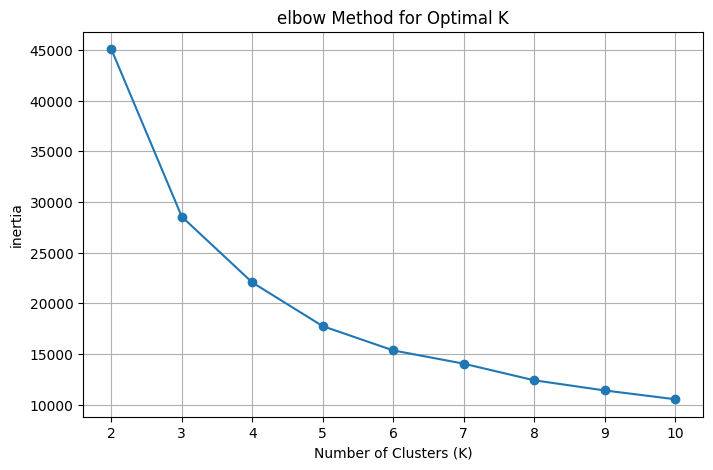

In [20]:
# plot elbow graph
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("inertia")
plt.title("elbow Method for Optimal K")
plt.grid(True)
plt.show()


In [21]:
# silhouette analysis to find optimal K
from sklearn.metrics import silhouette_score
silhouette_scores = [] # create silhouette scores list
K = range(2, 11) # set range of K values to try
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    silhouette_scores.append(score)


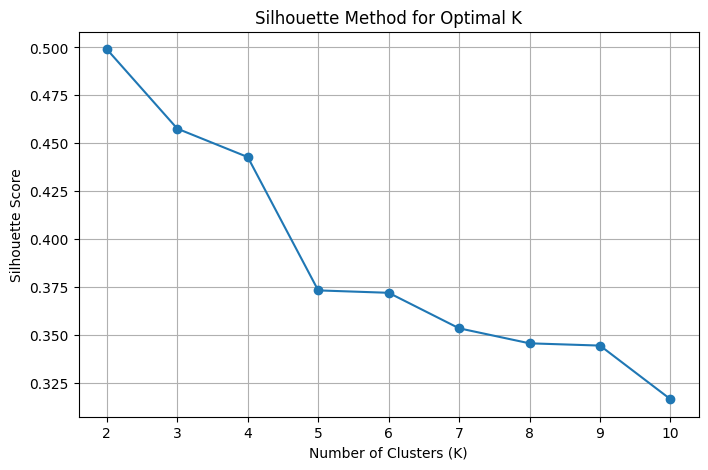

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal K")
plt.grid(True)
plt.show()


In [23]:
# fit KMeans with chosen K
k_chosen = 4
kmeans = KMeans(n_clusters = k_chosen, random_state=42)
kmeans.fit(X_scaled)
Labels = kmeans.labels_

In [24]:
# attach cluster labels to original dataframe
cleanF23['Cluster'] = Labels

# group by cluster and calculate mean values for each cluster
cluster_summary = cleanF23.groupby('Cluster').mean(numeric_only=True)
cluster_summary

,Age,Overall,Value,Wage
Cluster,,,,
0,27.259763,68.241614,1.964260e+06,7361.027386
1,20.096768,58.241027,6.244339e+05,1610.960738
2,26.728571,85.421429,6.551429e+07,156264.285714
3,26.744260,78.076010,1.646332e+07,48362.589074


Cluster 0 — Mid-Level, Lower-Rated Starters

Averages:

Age: 27.3

Overall: 68.2

Value: ~€1.96M

Wage: ~€7.36K

Interpretation:
These are mid-career players with below-average ratings. They aren’t prospects, but they also aren’t stars.
They have low market value and low wages, suggesting they are squad fillers, backups, or lower-division-quality players.

Cluster 1 — Very Young, Low-Overall but Overvalued Prospects

Averages:

Age: 20.1

Overall: 58.2

Value: ~€6.24M

Wage: ~€1.6K

Interpretation:
These are very young players (around 20) with low current performance, but surprisingly high market values.
This means they are high-potential prospects whose future ability is driving up their transfer values.
Clubs invest in them cheaply wage-wise, hoping they will become future stars.

Cluster 2 — Elite, High-Value Top Performers

Averages:

Age: 26.7

Overall: 85.4

Value: ~€65.5M

Wage: ~€156.6K

Interpretation:
These are superstar-level players in their prime.
They have very high ratings, huge transfer values, and top-tier wages.
This cluster contains the best talent, the players that teams build their squad around.

Cluster 3 — Strong Starters / Upper-Mid Tier Performers

Averages:

Age: 26.7

Overall: 78.1

Value: ~€16.4M

Wage: ~€48.3K

Interpretation:
These players are solid and reliable with strong ratings, just below elite.
They carry good value and decent wages, making them high-quality starters.
Think of them as the tier below the superstars in Cluster 2.

Quick Summary

Cluster 2 – Absolute elite players (superstars).

Cluster 3 – Strong starters, high performers but not elite.

Cluster 0 – Mid-level squad players with modest value.

Cluster 1 – Young, cheap wages but expensive prospects due to potential.

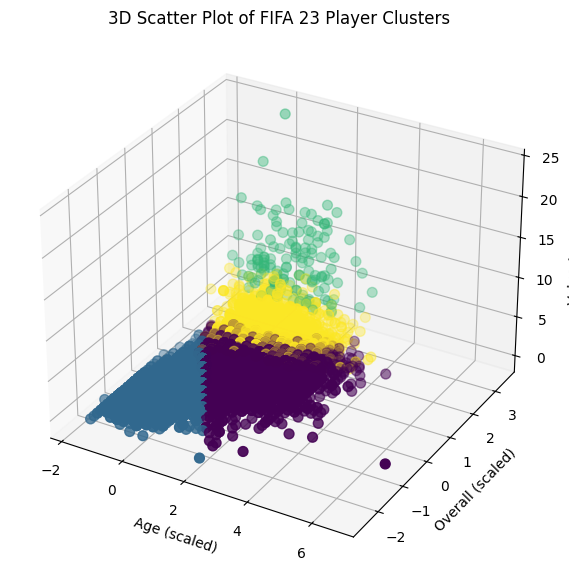

In [25]:
# plot 3D plot of clusters
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
    c=Labels, cmap='viridis', s=50
)
ax.set_xlabel('Age (scaled)')
ax.set_ylabel('Overall (scaled)')
ax.set_zlabel('Value (scaled)')
ax.set_title('3D Scatter Plot of FIFA 23 Player Clusters')
plt.show()

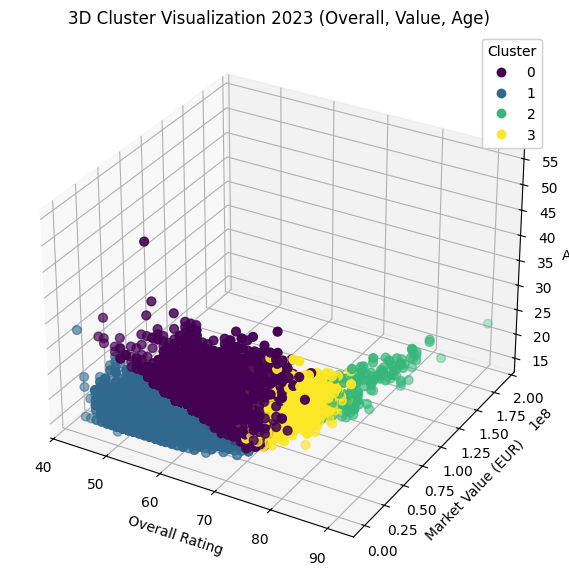

In [26]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    cleanF23['Overall'], 
    cleanF23['Value'], 
    cleanF23['Age'],
    c=cleanF23['Cluster'],    # color by cluster label
    cmap='viridis',           # color map
    s=40                      # point size
)

ax.set_xlabel('Overall Rating')
ax.set_ylabel('Market Value (EUR)')
ax.set_zlabel('Age')
ax.set_title('3D Cluster Visualization 2023 (Overall, Value, Age)')

legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)

plt.show()
